# Dataset subsetting
1. 정리해야 할 컬럼 확인
2. 엑셀에서 필터 작업을 하는 것처럼 각 컬럼에서 특정 값만 선택해서 확인
3. endpoint의 분포를 확인하고, 데이터 추가 확보하기 위한 방법 고민

In [1]:
import pandas as pd

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

In [2]:
df

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Assay,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,skin_irritation_invivo_18,In Vivo,NaN,NaN,Alcohol ethoxylate C12-15/E5 phosphate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
1,skin_irritation_invivo_83,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
2,skin_irritation_invivo_80,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate/...,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified/Possible irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
3,skin_irritation_invivo_822,In Vivo,MIX82,Captan 4L,Captan-related derivatives,NaN,NaN,0.970,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),NaN,NaN,NaN,NaN,NaN
4,skin_irritation_invivo_719,In Vivo,MIX380,Raid Roach & Ant Killer Plus,Dichlorvos-related compounds,NaN,NaN,0.014,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,skin_irritation_invivo_1222,In Vivo,MIX242,Fluopyram + Prothioconazole 400,Fluopyram,658066-35-4,DTXSID9058151,17.400,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),FC(F)(F)C1=CC(Cl)=C(CCNC(=O)C2=CC=CC=C2C(F)(F)...,Fluopyram,"658066-35-4|Fluopyram|AE C656948|Benzamide, N-...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
2054,skin_irritation_invivo_966,In Vivo,MIX242,Fluopyram + Prothioconazole 400,Fluopyram,658066-35-4,DTXSID9058151,17.400,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),FC(F)(F)C1=CC(Cl)=C(CCNC(=O)C2=CC=CC=C2C(F)(F)...,Fluopyram,"658066-35-4|Fluopyram|AE C656948|Benzamide, N-...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
2055,skin_irritation_invivo_824,In Vivo,MIX13,Abamectin B1a,Abamectin Component B1a,65195-55-3,DTXSID9058238,92.000,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),[H][C@@]12OCC3=C/C=C/[C@H](C)[C@H](O[C@@]4([H]...,Avermectin B1a,65195-55-3|Avermectin B1a|265-610-3|5-O-Demeth...,https://comptox.epa.gov/dashboard/chemical/det...,NaN
2056,skin_irritation_invivo_816,In Vivo,MIX13,Abamectin B1a,Abamectin Component B1a,65195-55-3,DTXSID9058238,92.000,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,EPA classification,4,Unitless,FIFRA (undated),[H][C@@]12OCC3=C/C=C/[C@H](C)[C@H](O[C@@]4([H]...,Avermectin B1a,65195-55-3|Avermectin B1a|265-610-3|5-O-Demeth...,https://comptox.epa.gov/dashboard/chemical/det...,NaN


In [3]:
#dataframe 전체 크기 확인
df.shape

(2058, 25)

In [4]:
#엑셀 컬럼 이름 확인 방법
df.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Concentration', 'Concentration_Units', 'Mixture', 'Species',
       'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS'],
      dtype='str')

In [5]:
#Mixture 컬럼 현황 확인
df['Mixture'].value_counts()

Mixture
Mixture     1799
Chemical     259
Name: count, dtype: int64

In [6]:
#Mixture 컬럼에서 chemical만 서낵
df_Chemical = df[df['Mixture']=='Chemical'] #chemical로 선택하면 아무 것도 선택이 안됩니다. 첫 글자를 소문자로 입력하면 발생하는 실수

# 2 종류의 에러
1. syntax 에러: 프로그래밍 문법에 어긋나서 발생하는 오류. 에러 메세지가 발생하면서 코드에서 잘못된 부분을 확인할 수 있게 도와줌.
2. sementics 에러: 프로그램 로직이 잘못되서 발생한 오류. 에러 메세지가 발생하지 않지만, 코드 실행 결과가 기대했던 결과와 다른 경우.
#### 두 에러 중 sementics 에러가 더 찾아내기 어려워요. 에러 메세지가 발생하지 않으니, 에러가 난 줄도 모르기 때문입니다.
##### 위에서 보이는 df[df['Mixture']]=='chemical'에서 chemical의 c를 소문자로 작성해서 발생한 오류는 sementics 에러에 해당되요.

In [7]:
df_Chemical

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Assay,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,skin_irritation_invivo_18,In Vivo,NaN,NaN,Alcohol ethoxylate C12-15/E5 phosphate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
1,skin_irritation_invivo_83,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
2,skin_irritation_invivo_80,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate/...,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified/Possible irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
5,skin_irritation_invivo_55,In Vivo,NaN,NaN,"N,N-Dimethyl-N-dodecyl amino- betaine",NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
6,skin_irritation_invivo_48,In Vivo,NaN,NaN,"Bis[(1-Methylimidazol)-(2- ethyl- hexanoate)],...",NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1969,skin_irritation_invivo_163,In Vivo,NaN,NaN,"4-Amino-1,2,4-triazole",584-13-4,DTXSID9033058,NaN,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,GHS classification,Not classified,Unitless,ICCVAM 2002; Not available; https://ntp.niehs....,NN1C=NN=C1,"4-Amino-1,2,4-triazole","584-13-4|4-Amino-1,2,4-triazole|1-Amino-1,3,4-...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
1970,skin_irritation_invivo_121,In Vivo,NaN,NaN,Boron trifluoride dehydrate,13319-75-0,DTXSID9033264,NaN,NaN,NaN,...,Draize Skin Irritation/Corrosion Test,GHS classification,1A,Unitless,ICCVAM 2002; Not available; https://ntp.niehs....,O.O.FB(F)F,Boron trifluoride dihydrate,13319-75-0|Boron trifluoride dihydrate|Boron f...,https://comptox.epa.gov/dashboard/chemical/det...,NaN
1971,skin_irritation_invivo_97,In Vivo,NaN,NaN,Boron trifluoride dihydrate,13319-75-0,DTXSID9033264,NaN,96,%,...,Draize Skin Irritation/Corrosion Test,GHS classification,1A,Unitless,ICCVAM 2002; Not available; https://ntp.niehs....,O.O.FB(F)F,Boron trifluoride dihydrate,13319-75-0|Boron trifluoride dihydrate|Boron f...,https://comptox.epa.gov/dashboard/chemical/det...,NaN
1972,skin_irritation_invivo_93,In Vivo,NaN,NaN,Phosphorus pentachloride,10026-13-8,DTXSID9033896,NaN,98,%,...,Draize Skin Irritation/Corrosion Test,GHS classification,1A,Unitless,ICCVAM 2002; Not available; https://ntp.niehs....,ClP(Cl)(Cl)(Cl)Cl,Phosphorus pentachloride,10026-13-8|Phosphorus pentachloride|[PCl5]|EIN...,https://comptox.epa.gov/dashboard/chemical/det...,NaN


In [8]:
#Chemical에서 C를 대문자로 입력하면 제대로 출력됨.
df_Chemical = df[df['Mixture']=='Chemical']

In [9]:
df_Chemical.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Assay,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,skin_irritation_invivo_18,In Vivo,NaN,NaN,Alcohol ethoxylate C12-15/E5 phosphate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
1,skin_irritation_invivo_83,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
2,skin_irritation_invivo_80,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate/...,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified/Possible irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
5,skin_irritation_invivo_55,In Vivo,NaN,NaN,"N,N-Dimethyl-N-dodecyl amino- betaine",NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
6,skin_irritation_invivo_48,In Vivo,NaN,NaN,"Bis[(1-Methylimidazol)-(2- ethyl- hexanoate)],...",NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,NaN,NaN,NaN,NaN,NaN


In [10]:
#subset 결과 검증. Mixture 컬럼에서 Chemical만 선택했기 때문에, subset한 dataframe의 Mixture 컬럼은 Chemical만 가지고 있어야 함.
df_Chemical['Mixture'].value_counts()

Mixture
Chemical    259
Name: count, dtype: int64

In [11]:
#Subset 후 species 정보가 얼마나 있는지 확인.
df_Chemical['Species'].value_counts()

Species
Human     180
Rabbit     79
Name: count, dtype: int64

In [12]:
#Mixture에서 Chemical만 선택하기 259개 row가 남은 상황
df_Chemical.shape

(259, 25)

In [13]:
#Species 컬럼에서 Human만 선택하기
df_human = df_Chemical[df_Chemical['Species']=='Human']

In [14]:
df_human.head(3) #head안에 넣은 숫자만큼 출력이 됩니다

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Assay,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,skin_irritation_invivo_18,In Vivo,NaN,NaN,Alcohol ethoxylate C12-15/E5 phosphate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
1,skin_irritation_invivo_83,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN
2,skin_irritation_invivo_80,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate/...,NaN,NaN,NaN,NaN,NaN,...,Four-hour Human Patch Test,Qualitative classification,Not classified/Possible irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN


In [15]:
df_human.shape #shape은 현재 저장된 dataframe의 row 수와 column수를 알려줍니다

(180, 25)

In [16]:
df_human['Endpoint'].value_counts() #valud_counts를 통해 Endpoint 안에 들어있는 값의 개수를 파악.

Endpoint
Qualitative classification    90
Positive reaction             90
Name: count, dtype: int64

In [17]:
df_class = df_human[df_human['Endpoint']=='Qualitative classification'] #df_human중에서 qualitative classification만 선택

In [18]:
df_class.shape

(90, 25)

In [19]:
df_class["Response"]

0                         Not classified
1                               Irritant
2       Not classified/Possible irritant
5                               Irritant
6                         Not classified
                      ...               
1849                      Not classified
1851                            Irritant
1857                      Not classified
1859                      Not classified
1861                      Not classified
Name: Response, Length: 90, dtype: str

In [20]:
df_class['Response'].value_counts()

Response
Not classified                      65
Irritant                            14
Not classified/Possible irritant     8
Irritant/Possible corrosive          3
Name: count, dtype: int64

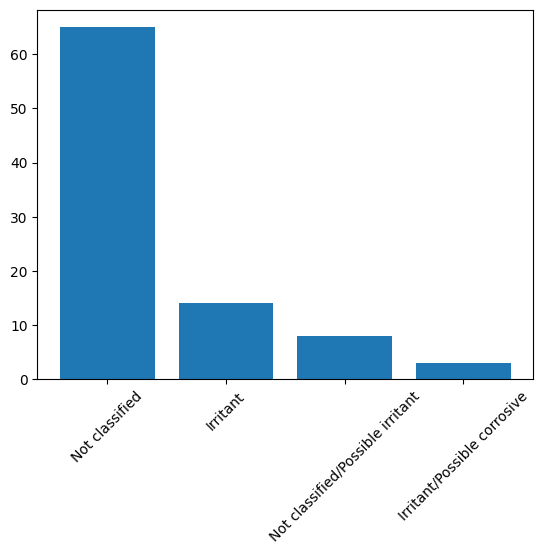

In [21]:
import matplotlib.pyplot as plt
#옛날에는 다 이렇게 plotting 했었어요. 지금은 AI가 너무 잘해줘서 plot할 때 직접 코딩하는 일이 많이 줄었습니다.
class_value = df_class['Response'].value_counts()
plt.bar(class_value.index, class_value)
plt.xticks(rotation=45)
plt.show()

In [22]:
df_reaction = df_human[df_human['Endpoint']=='Positive reaction']

In [23]:
df_reaction.shape

(90, 25)

In [24]:
df_reaction['Response'].value_counts()

Response
0        37
3.5       3
3.2       3
3.3       2
3.1       2
3.8       2
22.5      2
100       2
17.90     2
83.9      1
30        1
93.8      1
6.25      1
58.6      1
60.6      1
58.2      1
9.30      1
83.1      1
68.8      1
79.7      1
70.8      1
33.9      1
18        1
64.5      1
20        1
6.2       1
65.5      1
76.2      1
53.3      1
3.9       1
4.40      1
32.6      1
9.5       1
5.8       1
16.40     1
13.2      1
80.8      1
1.6       1
16.90     1
28.6      1
20.7      1
37.9      1
15.3      1
74.5      1
Name: count, dtype: int64

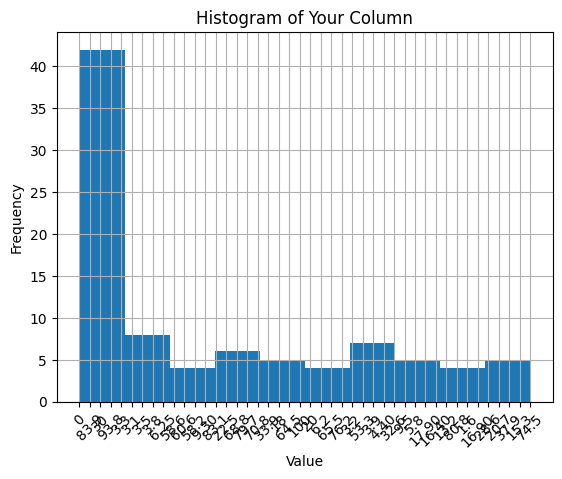

In [25]:
df_reaction['Response'].hist(bins=10)
plt.title('Histogram of Your Column')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()
#X축을 보시면 값이 이상하게 배열되어 있습니다.

In [26]:
df_reaction['Response'] #dtype 값이 str으로 나옵니다. 원래 파일에는 숫자와 글자가 섞여있어서 모든 숫자를 str로 저장해버렸나봐요.

10         0
14      83.9
15        30
16      93.8
17         0
        ... 
1850       0
1852    74.5
1858       0
1860       0
1862       0
Name: Response, Length: 90, dtype: str

In [27]:
df_reaction.loc[10,'Response']

'0'

In [28]:
type(df_reaction.loc[10,'Response'])

str

In [29]:
df_reaction['Response'] =  pd.to_numeric(df_reaction['Response'], errors='coerce') #perplexity가 알려준 type 변환 방법

In [30]:
df_reaction['Response'] #이제는 float64로 dtype이 바뀌었습니다

10       0.0
14      83.9
15      30.0
16      93.8
17       0.0
        ... 
1850     0.0
1852    74.5
1858     0.0
1860     0.0
1862     0.0
Name: Response, Length: 90, dtype: float64

In [31]:
df_reaction.loc[10,'Response']

np.float64(0.0)

In [32]:
type(df_reaction.loc[10,'Response'])

numpy.float64

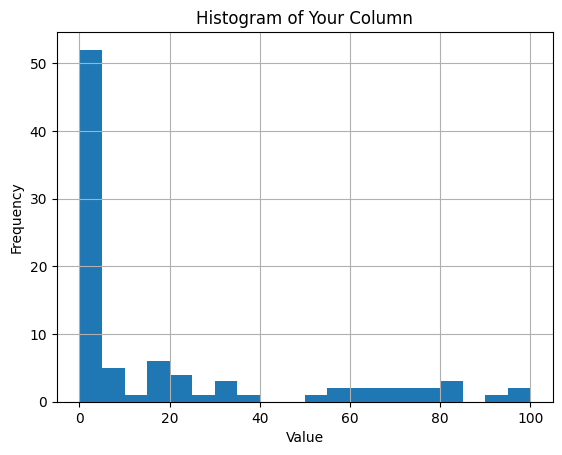

In [33]:
# type 변환 뒤 그린 histogram
df_reaction['Response'].hist(bins=20) #bins는 막대기 개수에요. 데이터 구간을 20등분 해서 숫자 계산한 후에 plot이 그려졌습니다.
plt.title('Histogram of Your Column')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [34]:
# subset을 한방에 하고 싶은 경우.
# df_chemical = df[df['Mixture']=='Chemical']
df['Mixture']=='Chemical'
# 아래에 출력되는 정보. Mixture 컬럼에 Chemical이라는 텍스트가 있는 줄은 True, 없는 줄은 False.

0        True
1        True
2        True
3       False
4       False
        ...  
2053    False
2054    False
2055    False
2056    False
2057    False
Name: Mixture, Length: 2058, dtype: bool

In [35]:
df_Chemical['Species']=='Human'

0        True
1        True
2        True
5        True
6        True
        ...  
1969    False
1970    False
1971    False
1972    False
1981    False
Name: Species, Length: 259, dtype: bool

In [36]:
(df_Chemical['Species']=='Human').sum()

np.int64(180)

# 파이썬 연산자
1. 더하기: +, 빼기: -, 곱하기: *, 나누기: / 외 다양한 연산자가 있습니다.
2. % 나머지를 구합니다.
3. ** 제곱 (2의 3승: 2**3) 
4. &는 and기호 입니다. 둘 다 True라면 True값이 나옵니다. 하나라도 False면 False로 표기.
5. |는 or기호 입니다. 하나라도 True면 True 값이 나옵니다. 둘다 False인 경우만 False.

In [37]:
(df['Mixture']=='Chemical') & (df['Species']=='Human')

0        True
1        True
2        True
3       False
4       False
        ...  
2053    False
2054    False
2055    False
2056    False
2057    False
Length: 2058, dtype: bool

In [38]:
#Mixture 컬럼이 Chemical이면서 Species 컬럼도 Human인 데이터는 180개
((df['Mixture']=='Chemical') & (df['Species']=='Human')).sum()

np.int64(180)

In [39]:
#Species가 Human이 아니더라도, Mixture 컬럼에 Chemical이 있으면 선택. (총 259개)
((df['Mixture']=='Chemical') | (df['Species']=='Human')).sum()

np.int64(259)

In [40]:
df_test = df[(df['Mixture']=='Chemical') & (df['Species']=='Human')]

In [41]:
df_test.shape

(180, 25)

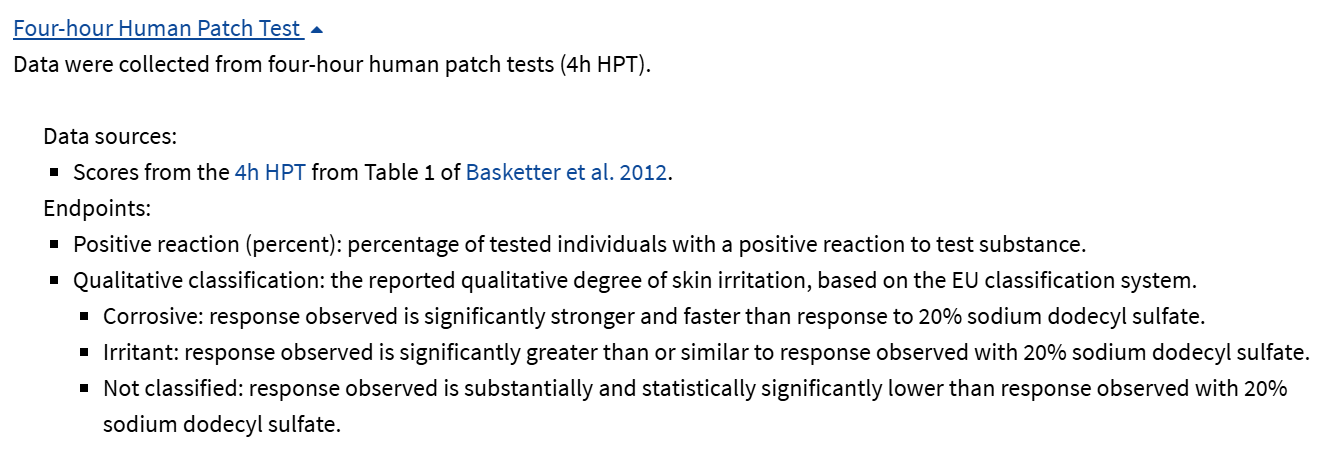
##### 수업하면서 실습을 빨리 끝내신 분들은, 데이터를 다양하게 분석하면서 최종 보고서에 들어갈 plot을 그려보시면 되겠습니다. (데이터에서 중요한 부분. 왜 이 endpoint를 선택했는가? 데이터 시각화를 invivo에 대해서만 했지만 invitro 데이터도 분포를 보고 비교해보시면 좋을 것 같네요)
1. 지금부터 진행할 실습. 데이터를 binary class로 통합해봅시다. 1(positive)와 0(negative)로 나눠보겠습니다.
2. df_reaction에는 positive reaction 값이 저장되어 있습니다. df_class에는 4개의 카테고리가 있습니다.
3. positive reaction은 테스트 물질에 대해 양성 반응을 보인 사람의 비율입니다. 0%는 아무도 반응이 없었다는 뜻으로 negative로 분류할 수 있습니다. 0% 보다 높으면 positive로 나눠볼게요.
4. qualitative classification에서 not classified는 실험은 수행했지만, 대조군보다도 response가 훨씬 낮았던 물질을 의미합니다. Not classified는 negative로 두고, 나머지 클래스는 positive로 분류해볼 수 있겠습니다.
5. df_reaction에 label이라는 컬럼을 새로 추가합니다. Response값이 0이면 label도 0, 0이 아니면 1로 입력.
6. df_class에도 label이라는 컬럼을 새로 추가합니다. Not classified인 경우 label은 0, 그 외의 값은 1로 입력합니다.
7. 최종 데이터는 pd.concat()을 이용해서 df_reaction과 df_class 2개를 합쳐서 최종 데이터를 만들어보겠습니다.
8. 최종 데이터를 concat한 후에는 to_csv()를 이용해서 파일로 저장.

In [42]:
'''
새로운 컬럼을 추가하는 방법
1. df[새롭게 추가할 컬럼 이름 작성]=임의의 값을 입력.
(새로운 컬럼을 추가한 후, 임의의 값으로 채우기)
2. 
'''
print('Before')
print(df.columns)
print('*'*80)

df['new'] = 0
print('After')
print(df.columns)
print('*'*80)

df = df.drop(['new'], axis=1)
print('Remove the new column again')
print(df.columns)

Before
Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Concentration', 'Concentration_Units', 'Mixture', 'Species',
       'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS'],
      dtype='str')
********************************************************************************
After
Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Concentration', 'Concentration_Units', 'Mixture', 'Species',
       'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS', 'new'],
      dtype='str')
*************************************************************

In [45]:
# =========================================
# 1. df_reaction label 만들기
# Response == 0 -> 0
# Response > 0 -> 1
# =========================================

df_reaction['label'] = (df_reaction['Response'] != 0).astype(int)

print(df_reaction[['Response', 'label']].head())
print(df_reaction['label'].value_counts())

    Response  label
10       0.0      0
14      83.9      1
15      30.0      1
16      93.8      1
17       0.0      0
label
1    53
0    37
Name: count, dtype: int64


In [46]:
# =========================================
# 2. df_class label 만들기
# Response == 'Not classified' -> 0
# 나머지 -> 1
# =========================================

df_class['label'] = (df_class['Response'] != 'Not classified').astype(int)

print(df_class[['Response', 'label']].head())
print(df_class['label'].value_counts())

                           Response  label
0                    Not classified      0
1                          Irritant      1
2  Not classified/Possible irritant      1
5                          Irritant      1
6                    Not classified      0
label
0    65
1    25
Name: count, dtype: int64


In [47]:
# =========================================
# 3. 데이터 합치기
# =========================================

df_final = pd.concat([df_reaction, df_class], axis=0)

print(df_final.shape)
print(df_final['label'].value_counts())

(180, 26)
label
0    102
1     78
Name: count, dtype: int64


In [48]:
# =========================================
# 4. csv 저장
# =========================================

df_final.to_csv('skin_irritation_binary.csv', index=False)

print('저장 완료!')

저장 완료!
